# Brownian Motion: Simulation and Variance Analysis

**Objective:** Simulate standard Brownian motion (SBM) trajectories and verify the theoretical $\mathcal{O}(\sqrt{t})$ diffusion scaling empirically.

### Theoretical Foundation
According to the standard definition, a stochastic process $(W_t)_{t \ge 0}$ is a standard Brownian motion if:
1. $W_0 = 0$ almost surely.
2. It has independent increments: for $0 \le s < t$, $W_t - W_s$ is independent of the past $\mathcal{F}_s$.
3. It has stationary, Gaussian increments: $W_t - W_s \sim \mathcal{N}(0, t-s)$.
4. Its sample paths $t \mapsto W_t$ are almost surely continuous.

The exact simulation relies on the independent increments property. By discretising time into steps of size $\Delta t$, we construct the path iteratively using $\Delta W_i \sim \mathcal{N}(0, \Delta t)$.

In [1]:
import os
import sys

# Append project root to path for local module imports
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt

from part01_brownian import simulation

### Trajectory Generation and Confidence Envelopes
We simulate $10,000$ paths to achieve strong statistical convergence. The plot includes a theoretical envelope of $\pm 2\text{std}$. Since $\text{Var}(W_t) = t$, the standard deviation grows as $\sqrt{t}$, meaning the $95\%$ confidence interval boundaries are exactly $y(t) = \pm 2\sqrt{t}$.

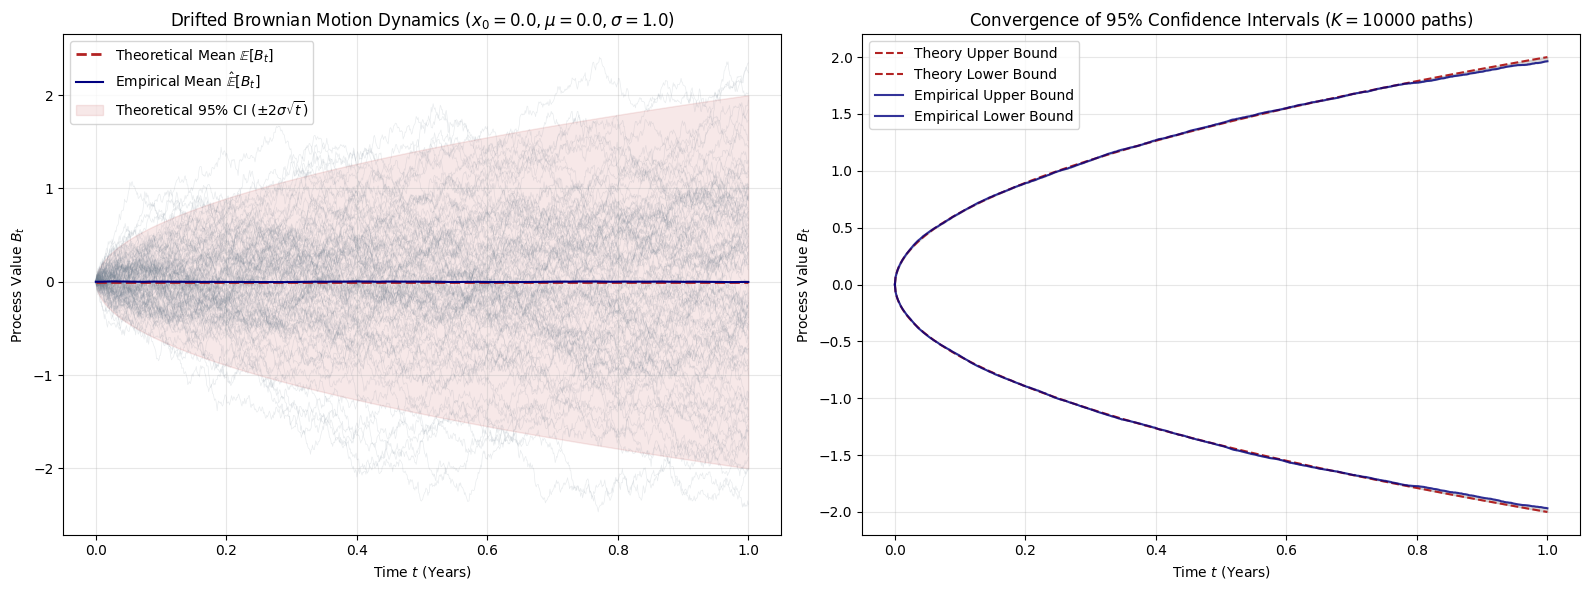

In [2]:
# Hyperparameters
T = 1.0
N = 1000
n_paths = 10000
dt = T / N
seed = 42

# Plotting trajectories
fig, axes = simulation.plot_trajectories(
    T, N, n_paths, mu=0.0, sigma=1.0, x0=0.0, seed=seed
)
plt.show()

### Empirical Observations
As expected, the paths form a funnel shape. The empirical spread of the $10,000$ simulated paths perfectly fits the theoretical $\pm 2\sqrt{t}$ envelope. This visually confirms that the variance of the simulated process scales linearly with time, a core property of continuous martingales.

### Financial Limitations
While fundamental to quantitative finance (e.g., Black-Scholes), standard Brownian motion is inadequate for direct asset price modelling:
* It can take negative values, violating the limited liability of equities.
* Its volatility is deterministic and constant, whereas empirical market volatility clusters and is stochastic.
* It generates continuous paths, failing to capture market jumps or macroeconomic shocks.

The next step in the pipeline addresses the first limitation by modeling log-returns through Geometric Brownian Motion (GBM).